# News Article Classification

## 1. Project Overview

In this project, we aim to build a Machine Learning model capable of classifying news articles into distinct topics (e.g., Sport, Business, Politics). This is a **Multi-Class Classification** problem. We will transform unstructured text data into numerical features using TF-IDF and train a predictive model to automatically assign categories to unseen articles.

### Project Roadmap

The project is structured as follows:

1.  **Exploratory Data Analysis (EDA):** Analyzing class distribution and text characteristics.
2.  **Text Preprocessing:** Cleaning text, removing stopwords, tokenization, and stemming to prepare data for modeling.
3.  **Feature Extraction:** Converting text into numerical vectors using **TF-IDF** (Term Frequency-Inverse Document Frequency).
4.  **Model Training:** Training a baseline model (Naive Bayes) and one with logistic regression.
5.  **Model Evaluation:** Assessing performance using Accuracy, Precision, Recall, F1-Score, and Confusion Matrix.
6.  **Inference:** Testing the trained model on completely new, custom news headlines.

In [7]:
# Environment Setup & Library Import

# Standard Data Science Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# NLP Libraries

import re
import nltk
from nltk.stem import PorterStemmer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# Scikit-Learn (Machine Learning & Feature Extraction)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Configuration

%matplotlib inline
sns.set_style("whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load dataset

file_path = 'bbc-text.csv'

try:
    df = pd.read_csv(file_path)
    print(f"Dataset loaded successfully from '{file_path}'")
    print(f"Shape: {df.shape}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please check the file path.")

# Inspect first rows

display(df.head())

# Check for nulls

print("\nMissing values:")
print(df.isnull().sum())

Dataset loaded successfully from 'bbc-text.csv'
Shape: (2225, 2)


,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...



Missing values:
category    0
text        0
dtype: int64


# 1. Exploratory Data Analysis (EDA)

Understanding the dataset structure is critical. We will analyze:
1.  **Class Distribution:** To check if the dataset is balanced.
2.  **Text Length Distribution:** To see how long the articles are on average.

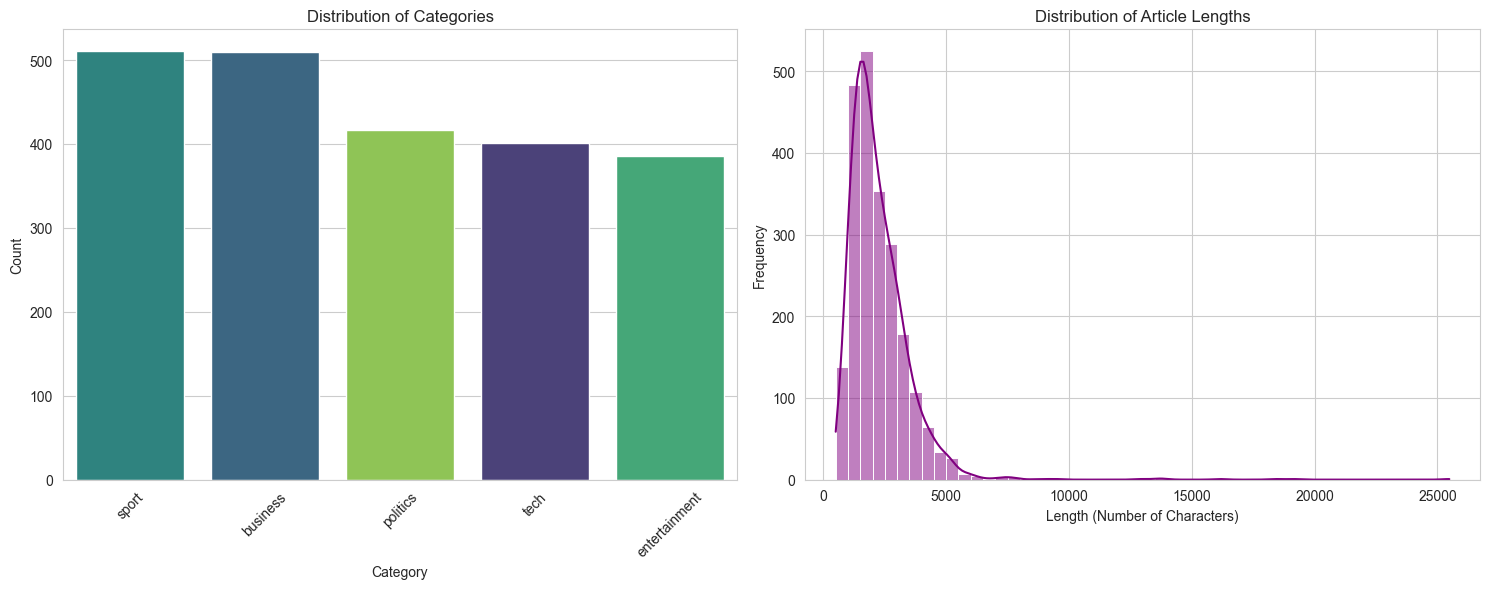

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   category     2225 non-null   object
 1   text         2225 non-null   object
 2   text_length  2225 non-null   int64 
 3   clean_text   2225 non-null   object
dtypes: int64(1), object(3)
memory usage: 69.7+ KB

Class Counts:
category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

Average Article Length: 2262 characters


In [16]:
# Data Visualization

# Create a figure with two subplots (side by side)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Class Distribution

sns.countplot(
    x='category', 
    data=df, 
    hue='category',
    palette='viridis', 
    legend=False,
    order=df['category'].value_counts().index, 
    ax=ax[0]
)
ax[0].set_title('Distribution of Categories')
ax[0].set_xlabel('Category')
ax[0].set_ylabel('Count')
ax[0].tick_params(axis='x', rotation=45)

# 2. Text Length Distribution (Create a temporary column for length (number of characters))

df['text_length'] = df['text'].apply(len)

sns.histplot(df['text_length'], bins=50, kde=True, color='purple', ax=ax[1])
ax[1].set_title('Distribution of Article Lengths')
ax[1].set_xlabel('Length (Number of Characters)')
ax[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Print numerical stats

df.info()
print()
print("Class Counts:")
print(df['category'].value_counts())
print("\nAverage Article Length:", int(df['text_length'].mean()), "characters")

# 2. Text Preprocessing

Raw text data contains noise that can negatively affect model performance. We will implement a preprocessing pipeline to clean the data.

**The Pipeline:**
1.  **Cleaning:** Remove non-alphabetic characters (punctuation, numbers, special symbols) using Regex.
2.  **Lowercasing:** Convert all text to lowercase to ensure uniformity (e.g., "Sport" == "sport").
3.  **Tokenization:** Split sentences into individual words.
4.  **Stopwords Removal:** Remove common words (e.g., "and", "the", "is") that add little semantic value.
5.  **Stemming:** Reduce words to their root form (e.g., "running" -> "run") using the **Porter Stemmer**.

In [10]:
# Text Preprocessing

# Initialize the Stemmer

stemmer = PorterStemmer()

# Define the preprocessing function

def preprocess_text(text):

    # 1. Remove non-alphabetic characters (keep only letters and spaces)

    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # 2. Convert to lowercase

    text = text.lower()
    
    # 3. Tokenize (split by whitespace)

    words = text.split()
    
    # 4. Remove stopwords & 5. Apply Stemming

    clean_words = [stemmer.stem(word) for word in words if word not in ENGLISH_STOP_WORDS]
    
    # Join the words back into a single string

    return ' '.join(clean_words)

# Apply the function to the 'text' column

print("Preprocessing text... Please wait.")
df['clean_text'] = df['text'].apply(preprocess_text)

print("Preprocessing complete!")

# Inspect the transformation (Before vs After)

display(df[['text', 'clean_text']].head())

Preprocessing text... Please wait.
Preprocessing complete!


,text,clean_text
0,tv future in the hands of viewers with home th...,tv futur hand viewer home theatr system plasma...
1,worldcom boss left books alone former worldc...,worldcom boss left book worldcom boss berni eb...
2,tigers wary of farrell gamble leicester say ...,tiger wari farrel gambl leicest say rush make ...
3,yeading face newcastle in fa cup premiership s...,yead face newcastl fa cup premiership newcastl...
4,ocean s twelve raids box office ocean s twelve...,ocean s raid box offic ocean s crime caper seq...


# 3. Feature Extraction (TF-IDF) & Data Splitting

Now we convert the text data into numerical vectors using **TF-IDF (Term Frequency - Inverse Document Frequency)**.

**Steps:**
1.  **Vectorization:** Transform `clean_text` into a matrix of numbers where each row is an article and each column is a word. We limit features to the top 5,000 most frequent words to avoid dimensionality issues.
2.  **Train-Test Split:** Split the dataset into Training set (80%) and Test set (20%) to evaluate the model fairly on unseen data.

In [13]:
# Initialize TF-IDF Vectorizer

# max_features=5000: We only keep the top 5k most frequent words to reduce noise

tfidf = TfidfVectorizer(max_features=5000)

# Fit and Transform the text data

X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['category']

print(f"Feature Matrix Shape (Articles, Words): {X.shape}")

# Split Data into Train and Test sets (80% Train, 20% Test)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

# 3. Data Splitting (Modified for Pipeline)

# Instead of vectorizing first, we split the TEXT data directly.
# The Pipeline will handle vectorization inside the training process.

X = df['clean_text'] # Input features (Text)
y = df['category']   # Target labels

print(f"Total Samples: {X.shape[0]}")

# Split Data into Train and Test sets (80% Train, 20% Test)
# Note: X_train and X_test are now pandas Series of text strings, not matrices!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training Set Shape: {X_train.shape}")
print(f"Test Set Shape: {X_test.shape}")

Feature Matrix Shape (Articles, Words): (2225, 5000)
Training Set Shape: (1780, 5000)
Test Set Shape: (445, 5000)


# 4. Model Training

We will train a **Multinomial Naive Bayes (MNB)** classifier. This algorithm is particularly suited for text classification problems with discrete features (like word counts or TF-IDF vectors).

**Why Naive Bayes?**

* Computationally efficient.
* Performs very well on high-dimensional data (many words).
* Robust baseline for NLP tasks.

In [25]:
# Initialize the Model

model = MultinomialNB()

# Train the Model

print("Training the model... this might take a moment.")
model.fit(X_train, y_train)

print("Model trained successfully!")

Training the model... this might take a moment.
Model trained successfully!


# 5. Model Evaluation

We evaluate the model using the Test Set (unseen data).

**Key Metrics:**

* **Accuracy:** Overall percentage of correct predictions.
* **Confusion Matrix:** Visualizes misclassifications (e.g., how many 'Tech' articles were wrongly predicted as 'Business').
* **Classification Report:** Detailed precision, recall, and F1-score for each category.

Model Accuracy: 98.20%

Classification Report:
               precision    recall  f1-score   support

     business       0.97      0.97      0.97       102
entertainment       0.99      0.97      0.98        77
     politics       0.95      0.99      0.97        84
        sport       1.00      1.00      1.00       102
         tech       1.00      0.97      0.99        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



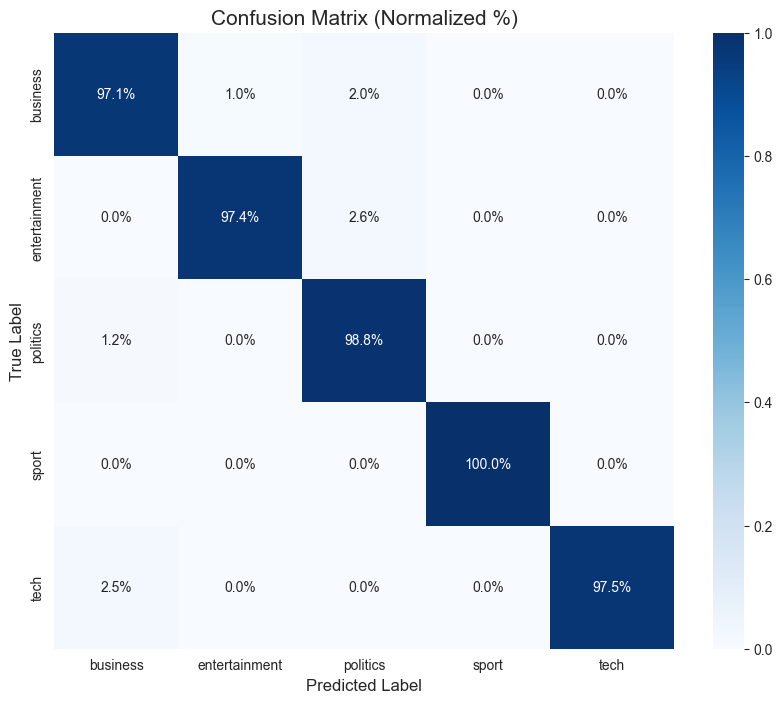

In [28]:
# Make Predictions on the Test Set

y_pred = model.predict(X_test)

# Calculate Accuracy

acc = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {acc:.2%}\n")

# Detailed Classification Report

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix (%)

conf_matrix = confusion_matrix(y_test, y_pred)

# Normalize the matrix to get percentages (Row-wise normalization)
# We divide each value by the sum of its row (True Label count)

conf_matrix_pct = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    conf_matrix_pct, 
    annot=True, 
    fmt='.1%',   
    cmap='Blues',
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.title('Confusion Matrix (Normalized %)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# 6. Model Comparison: Logistic Regression

While Naive Bayes is a strong baseline, **Logistic Regression** is often more robust for text classification as it learns the relationship between features and labels discriminatively. We will train it and compare its performance.

Training Logistic Regression...
Training complete!

Logistic Regression Accuracy: 97.98%
------------------------------
               precision    recall  f1-score   support

     business       0.98      0.97      0.98       102
entertainment       0.96      1.00      0.98        77
     politics       0.98      0.96      0.97        84
        sport       1.00      1.00      1.00       102
         tech       0.97      0.96      0.97        80

     accuracy                           0.98       445
    macro avg       0.98      0.98      0.98       445
 weighted avg       0.98      0.98      0.98       445



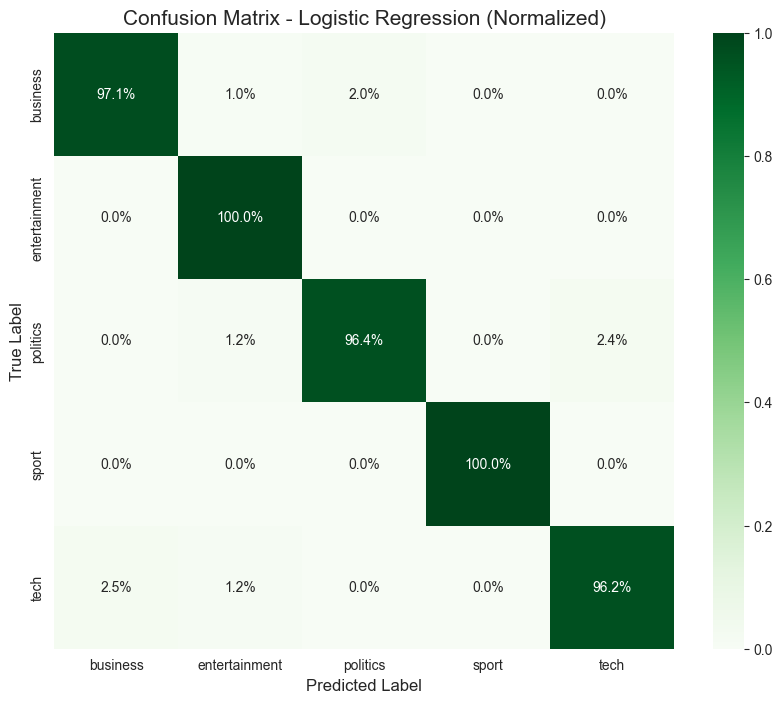

In [33]:
# Initialize Logistic Regression and train the Model

log_reg = LogisticRegression(max_iter=1000, random_state=42)

print("Training Logistic Regression...")
log_reg.fit(X_train, y_train)
print("Training complete!")

# Evaluate

y_pred_log = log_reg.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

print(f"\nLogistic Regression Accuracy: {acc_log:.2%}")
print("-" * 30)
print(classification_report(y_test, y_pred_log))

# Visualize Confusion Matrix

cm_log = confusion_matrix(y_test, y_pred_log)

# Normalize to percentages

cm_log_pct = cm_log.astype('float') / cm_log.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_log_pct, 
    annot=True, 
    fmt='.1%', 
    cmap='Greens', # Changed color to Greens to distinguish from Naive Bayes (Blues)
    xticklabels=log_reg.classes_,
    yticklabels=log_reg.classes_
)
plt.title('Confusion Matrix - Logistic Regression (Normalized)', fontsize=15)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.show()

# 7. Inference on New Data

The model is trained and evaluated. Now we test it on completely new, unseen headlines created manually.
We must use the **same preprocessing pipeline** and the **same TF-IDF vectorizer** (using `.transform()`) to ensure consistency.

In [30]:
# List of new, made-up headlines

new_articles = [
    "Apple releases the new iPhone with a revolutionary AI processor",       # Tech
    "The government announces a cut in tax rates for small businesses",      # Business / Politics
    "Manchester United wins the championship after a dramatic final match",  # Sport
    "The new blockbuster movie breaks all box office records this weekend",  # Entertainment
    "The prime minister is discussing new laws in the parliament"            # Politics
]

print("Predictions on New Data:\n")
print(f"{'PREDICTION':<15} | {'TEXT'}")
print("-" * 100)

for article in new_articles:

    # 1. Preprocess the raw text

    cleaned_article = preprocess_text(article)
    
    # 2. Vectorize (Use .transform, NOT .fit_transform!)

    vectorized_article = tfidf.transform([cleaned_article]).toarray()
    
    # 3. Predict
    
    prediction = model.predict(vectorized_article)[0]
    
    print(f"{prediction:<15} | {article}")

Predictions on New Data:

PREDICTION      | TEXT
----------------------------------------------------------------------------------------------------
tech            | Apple releases the new iPhone with a revolutionary AI processor
business        | The government announces a cut in tax rates for small businesses
sport           | Manchester United wins the championship after a dramatic final match
entertainment   | The new blockbuster movie breaks all box office records this weekend
politics        | The prime minister is discussing new laws in the parliament


# 8. Saving the Best Model

After comparing Multinomial Naive Bayes (Accuracy: 98.20%) and Logistic Regression (Accuracy: 97.98%), we selected **Naive Bayes** as our production model due to its slightly superior performance, but crucially for its computational efficiency.

We verify the pipeline by loading the saved artifacts and running a prediction check.

In [34]:
# Saving model and tf-idf vectorizer using Pickle

import pickle
import os

# Define filenames

model_filename = 'news_classifier_model.pkl'
vectorizer_filename = 'tfidf_vectorizer.pkl'

# Save the Model (Naive Bayes) and the Vectorizer

with open(model_filename, 'wb') as file:
    pickle.dump(model, file)

with open(vectorizer_filename, 'wb') as file:
    pickle.dump(tfidf, file)

print(f"Artifacts saved successfully:\n- {model_filename}\n- {vectorizer_filename}")

# Verification Step (Simulate Production Environment)

print("\n--- Production Verification Test ---")

# Load artifacts from disk

with open(vectorizer_filename, 'rb') as f:
    prod_tfidf = pickle.load(f)
with open(model_filename, 'rb') as f:
    prod_model = pickle.load(f)

# Test inputs

test_samples = [
    "The central bank raises interest rates to fight inflation", # Expected: Business
    "Lionel Messi scores a hat-trick in the champions league"    # Expected: Sport
]

print(f"{'TEXT (Truncated)':<50} | {'PREDICTION'}")
print("-" * 70)

for text in test_samples:
    # Preprocess -> Vectorize -> Predict
    clean_txt = preprocess_text(text)
    vec_txt = prod_tfidf.transform([clean_txt]).toarray()
    pred = prod_model.predict(vec_txt)[0]
    
    print(f"{text:<50} | {pred}")

Artifacts saved successfully:
- news_classifier_model.pkl
- tfidf_vectorizer.pkl

--- Production Verification Test ---
TEXT (Truncated)                                   | PREDICTION
----------------------------------------------------------------------
The central bank raises interest rates to fight inflation | business
Lionel Messi scores a hat-trick in the champions league | sport
